In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import math
import random
import seaborn as sns
import matplotlib.pyplot as plt
# Sirve para medir la velocidad de una función
import time
%load_ext line_profiler
import sys
sys.path.insert(1, '/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Codigos/Funciones_utiles')
import funciones_aux_bootstrap as fab
from matplotlib import legend_handler

# Fijamos el estilo de la gráfica
plt.style.use('petroff10')

In [2]:
# Importamos los datos para el análisis
df_act_yuc_i=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases/Base elecciones analsis/base_elecciones_yuc_analsis.csv", index_col=0)
df_act_yuc_i

,ID ESTADO,NOMBRE ESTADO,DISTRITO,SECCION,CASILLA,ID CASILLA,ESTATUS ACTA,PAN,PRI,PRD,...,CANDIDATOS NO REGISTRADOS,VOTOS NULOS,LISTA NOMINAL,TOTAL,PARTICIPACIÓN,JOAQUIN_DIAZ_MENA,RENAN_BARRERA_CONCHA,VIDA_ARAVARI_GOMEZ_HERRERA,YAMIL_JASMIN_LOPEZ_MANRIQUE,VOTOS_NULOS_CAND_NO_REGIS
0,31,YUCATÁN,12,1,'0001B1,1,COMPUTADA,171.0,107.0,3.0,...,0.0,12.0,596.0,532.0,0.892617,209.0,290.0,18.0,3.0,12.0
1,31,YUCATÁN,12,1,'0001C1,2,COMPUTADA,177.0,104.0,0.0,...,0.0,11.0,596.0,547.0,0.917785,208.0,299.0,29.0,0.0,11.0
2,31,YUCATÁN,12,1,'0001C2,3,COMPUTADA,176.0,100.0,1.0,...,0.0,13.0,595.0,542.0,0.910924,228.0,289.0,11.0,1.0,13.0
3,31,YUCATÁN,12,2,'0002B1,4,COMPUTADA,46.0,33.0,2.0,...,0.0,3.0,174.0,162.0,0.931034,71.0,79.0,7.0,2.0,3.0
4,31,YUCATÁN,12,4,'0004B1,6,COMPUTADA,110.0,96.0,7.0,...,0.0,14.0,550.0,513.0,0.932727,275.0,207.0,10.0,7.0,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2836,31,YUCATÁN,3,1195,'1195V1,2967,COMPUTADA,2.0,0.0,0.0,...,0.0,0.0,0.0,2.0,0.000000,0.0,2.0,0.0,0.0,0.0
2837,31,YUCATÁN,5,1197,'1197V1,2969,COMPUTADA,2.0,1.0,0.0,...,0.0,0.0,0.0,5.0,0.000000,2.0,3.0,0.0,0.0,0.0
2838,31,YUCATÁN,8,1199,'1199V1,2971,COMPUTADA,2.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.000000,1.0,2.0,0.0,0.0,0.0
2839,31,YUCATÁN,9,1200,'1200V1,2972,COMPUTADA,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.000000,1.0,0.0,0.0,0.0,0.0


In [3]:
df_act_yuc_i.TOTAL.mean()*400

np.float64(171588.45476944736)

In [4]:
# Datos reales de la proporción
prop_reales=df_act_yuc_i[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum()/df_act_yuc_i[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum().sum()
prop_reales

JOAQUIN_DIAZ_MENA              0.515125
RENAN_BARRERA_CONCHA           0.421366
VIDA_ARAVARI_GOMEZ_HERRERA     0.036792
YAMIL_JASMIN_LOPEZ_MANRIQUE    0.005249
VOTOS_NULOS_CAND_NO_REGIS      0.021467
dtype: float64

## Comparación bootstraps sin estratificar

In [5]:
# Leemos las bases

# Base de bootstrap por casillas sin estratificar
df_boostraps_c_s_e=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases finales rep/Bootstrap por casillas/Distintas_muestras_casillas_bootstrap_sin_est_f_1.csv", index_col=0)
# Base de bootstrap por votos (directo)
df_boostraps_votos_se=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases finales rep/Bootstrap votos/Metodo 1/Distintas_muestras_submuestras_bootstrap_votos_met_1_sin_est_f_1.csv", index_col=0)

## Reducción del error

In [6]:
# Por casillas
1-df_boostraps_c_s_e["Error_maximo_mediana"].min()/df_boostraps_c_s_e["Error_maximo_mediana"].max()

np.float64(0.5391096616175091)

In [7]:
# Por casillas luego votos
b=df_boostraps_votos_se.groupby('Tamaño_submuestra_votos').agg({'Error_maximo_mediana':['max','min']})
b.columns=b.columns.map('_'.join)
b=b.reset_index()
b["Reduccion"]=1-b["Error_maximo_mediana_min"]/b["Error_maximo_mediana_max"]
b

,Tamaño_submuestra_votos,Error_maximo_mediana_max,Error_maximo_mediana_min,Reduccion
0,500,0.021258,0.019415,0.086675
1,1000,0.018606,0.014235,0.234903
2,2000,0.014939,0.010738,0.281177
3,5000,0.012566,0.008148,0.351607
4,10000,0.011357,0.006725,0.407820
5,20000,0.011728,0.006088,0.480915


## Reducción intervalo más largo

In [8]:
# Por casillas
1-df_boostraps_c_s_e["Intervalo_M_grande_inter_mediana"].min()/df_boostraps_c_s_e["Intervalo_M_grande_inter_mediana"].max()

np.float64(0.46589893084468936)

In [9]:
# Por casillas luego votos
a=df_boostraps_votos_se.groupby('Tamaño_submuestra_votos').agg({'Intervalo_M_grande_inter_mediana':['max','min']})
a.columns=a.columns.map('_'.join)
a=a.reset_index()
a["Reduccion"]=1-a["Intervalo_M_grande_inter_mediana_min"]/a["Intervalo_M_grande_inter_mediana_max"]
a

,Tamaño_submuestra_votos,Intervalo_M_grande_inter_mediana_max,Intervalo_M_grande_inter_mediana_min,Reduccion
0,500,0.087068,0.086840,0.002621
1,1000,0.061699,0.061472,0.003684
2,2000,0.043618,0.043436,0.004171
3,5000,0.027668,0.027583,0.003061
4,10000,0.019609,0.019523,0.004360
5,20000,0.013914,0.013859,0.003961


## Gráficas

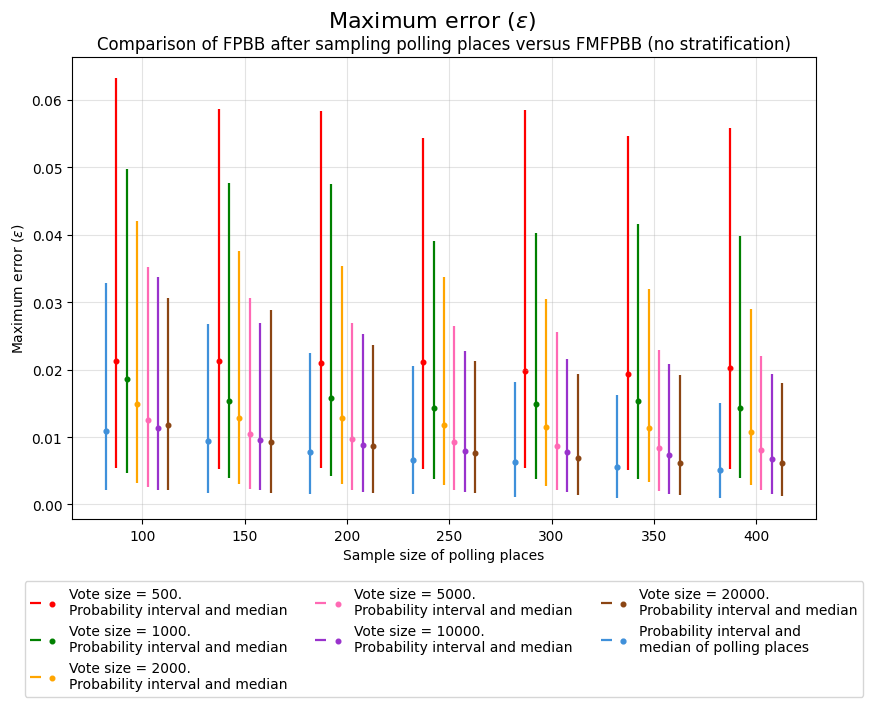

In [14]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(9.6, 6), dpi=100)
# Guardar la gráfica
#fig = plt.figure(figsize=(9.6, 6), dpi=350)
ax = fig.add_subplot(111)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]

# Lista de los labels de las gráficas
labels_votos = []

# Lista para guardar las gráficas
lista_graficas = []

# Para que no se crucen las líneas
offset = 5.1

# Primero hacemos un for para crear los valores para que no crucen las líneas
valores_x_grafica=[]
for ind_j, j in enumerate(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique()):
    k = 0
    for ind_i, i in enumerate(df_boostraps_votos_se["Tamaño_muestra_casillas"].unique()):

        # Slightly offset the x position for each subcategory
        valores_x_grafica.append( i + (ind_j - (len(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique())+1) / 2) * offset)


# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique()):
    l=0
    for ind_i, i in enumerate(df_boostraps_votos_se["Tamaño_muestra_casillas"].unique()):
              
        if l==0:
            # Slightly offset the x position for each subcategory
            x_position = i + (ind_j+1 - (len(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique())+1) / 2) * offset

            # Guardamos en lista los labels
            labels_votos.append(f"Vote size = {j}. \nProbability interval and median")
            linea_1=ax.vlines(
                x_position,
                df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Error_maximo_q_025"].iloc[0],
                df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Error_maximo_q_975"].iloc[0],
                color=colors_plot[ind_j],
                linestyle="solid",
                label=f"Muestra votos = {j} (sin estratificar)",
                linewidth=1.6
            )
            punto_1=plt.scatter(x_position, df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Error_maximo_mediana"].iloc[0], color=colors_plot[ind_j], s=11)
            
            # Para que aparezcan los nombres
            lista_graficas.append((linea_1, punto_1))


        else:
            # Slightly offset the x position for each subcategory
            x_position = i + (ind_j+1 - (len(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique())+1) / 2) * offset

            # Guardamos en lista los labels
            #labels_votos.append(f"Sample size of votes = {j}. \nProbability interval and median")
            ax.vlines(
                x_position,
                df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Error_maximo_q_025"].iloc[0],
                df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Error_maximo_q_975"].iloc[0],
                color=colors_plot[ind_j],
                linestyle="solid",
                linewidth=1.6
            )
            plt.scatter(x_position, df_boostraps_votos_se[
            (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
            & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
        ]["Error_maximo_mediana"].iloc[0], color=colors_plot[ind_j], s=11)
            
        l=l+1


k=0

# Las gráficas de los intervalos de probabilidad de las casillas
for ind_i, i in enumerate(df_boostraps_c_s_e["Tamaño_muestra_casillas"].unique()):

    if k==0:
        x_position = valores_x_grafica[ind_i]
        # Guardamos en lista los labels
        labels_votos.append(f"Probability interval and \nmedian of polling places")
        linea_2=ax.vlines(
            x_position,
            df_boostraps_c_s_e[
                (df_boostraps_c_s_e["Tamaño_muestra_casillas"] == i)
            ]["Error_maximo_q_025"].iloc[0],
            df_boostraps_c_s_e[
                (df_boostraps_c_s_e["Tamaño_muestra_casillas"] == i)
            ]["Error_maximo_q_975"].iloc[0],
            linestyle="solid",
            label=f"Polling places",
            linewidth=1.6
        )
        # Graficamos las medianas
        punto_2=ax.scatter(x_position,df_boostraps_c_s_e[(df_boostraps_c_s_e["Tamaño_muestra_casillas"]==i)]["Error_maximo_mediana"].iloc[0], color='C0', s=12)
        # Para que aparezcan los nombres
        lista_graficas.append((linea_2, punto_2))
    else:
        x_position = valores_x_grafica[ind_i]
        # Guardamos en lista los labels
        #labels_votos.append(f"Probability interval of \npolling places")
        ax.vlines(
            x_position,
            df_boostraps_c_s_e[
                (df_boostraps_c_s_e["Tamaño_muestra_casillas"] == i)
            ]["Error_maximo_q_025"].iloc[0],
            df_boostraps_c_s_e[
                (df_boostraps_c_s_e["Tamaño_muestra_casillas"] == i)
            ]["Error_maximo_q_975"].iloc[0],
            linestyle="solid",
            linewidth=1.6
        )
        # Graficamos las medianas
        ax.scatter(x_position,df_boostraps_c_s_e[(df_boostraps_c_s_e["Tamaño_muestra_casillas"]==i)]["Error_maximo_mediana"].iloc[0], color='C0', s=12)
    k=l+1


# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.12), ncol=2, loc="upper center", numpoints=1)

lgnd = ax.legend(lista_graficas, labels_votos, bbox_to_anchor=(0.5, -0.12), ncol=3, loc="upper center", numpoints=1, handler_map = {tuple: legend_handler.HandlerTuple(None)})

plt.suptitle("Maximum error ($\\epsilon$)", fontsize=16, y=0.96)
plt.title("Comparison of FPBB after sampling polling places versus FMFPBB (no stratification)")

plt.xlabel("Sample size of polling places")
plt.ylabel("Maximum error ($\\epsilon$)")

plt.grid(alpha=0.35)

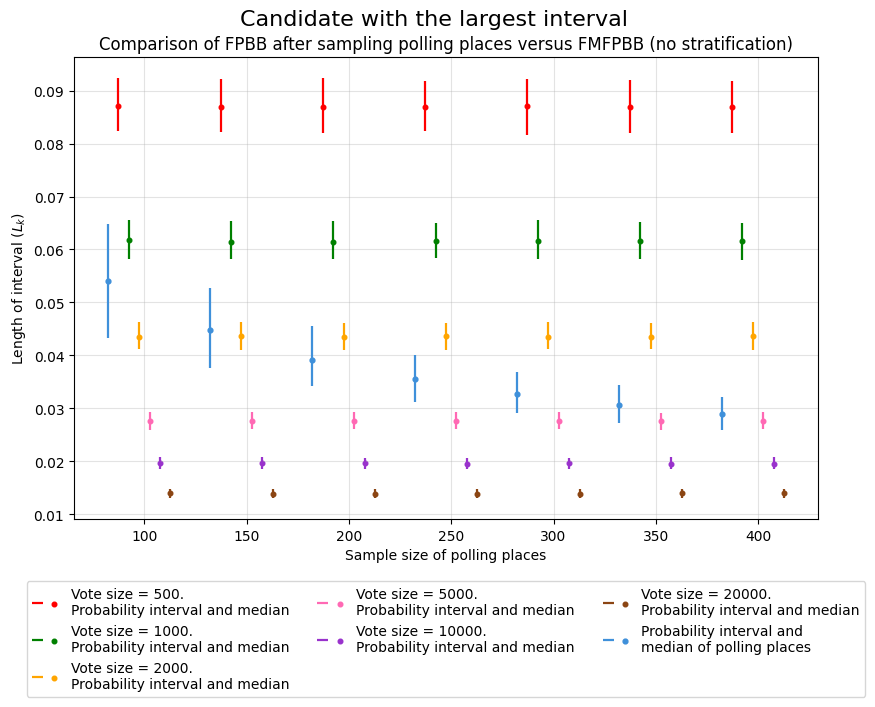

In [17]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(9.6, 6), dpi=100)
# Guardar la gráfica
#fig = plt.figure(figsize=(9.6, 6), dpi=350)
ax = fig.add_subplot(111)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]

# Lista de los labels de las gráficas
labels_votos = []

# Lista para guardar las gráficas
lista_graficas = []

# Para que no se crucen las líneas
offset = 5.1

# Primero hacemos un for para crear los valores para que no crucen las líneas
valores_x_grafica=[]
for ind_j, j in enumerate(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique()):
    k = 0
    for ind_i, i in enumerate(df_boostraps_votos_se["Tamaño_muestra_casillas"].unique()):

        # Slightly offset the x position for each subcategory
        valores_x_grafica.append( i + (ind_j - (len(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique())+1) / 2) * offset)


# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique()):
    l=0
    for ind_i, i in enumerate(df_boostraps_votos_se["Tamaño_muestra_casillas"].unique()):
              
        if l==0:
            # Slightly offset the x position for each subcategory
            x_position = i + (ind_j+1 - (len(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique())+1) / 2) * offset

            # Guardamos en lista los labels
            labels_votos.append(f"Vote size = {j}. \nProbability interval and median")
            linea_1=ax.vlines(
                x_position,
                df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Intervalo_M_grande_inter_q_025"].iloc[0],
                df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Intervalo_M_grande_inter_q_975"].iloc[0],
                color=colors_plot[ind_j],
                linestyle="solid",
                label=f"Muestra votos = {j} (sin estratificar)",
                linewidth=1.6
            )
            punto_1=plt.scatter(x_position, df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Intervalo_M_grande_inter_mediana"].iloc[0], color=colors_plot[ind_j], s=11)
            
            # Para que aparezcan los nombres
            lista_graficas.append((linea_1, punto_1))


        else:
            # Slightly offset the x position for each subcategory
            x_position = i + (ind_j+1 - (len(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique())+1) / 2) * offset

            # Guardamos en lista los labels
            #labels_votos.append(f"Sample size of votes = {j}. \nProbability interval and median")
            ax.vlines(
                x_position,
                df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Intervalo_M_grande_inter_q_025"].iloc[0],
                df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Intervalo_M_grande_inter_q_975"].iloc[0],
                color=colors_plot[ind_j],
                linestyle="solid",
                linewidth=1.6
            )
            plt.scatter(x_position, df_boostraps_votos_se[
            (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
            & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
        ]["Intervalo_M_grande_inter_mediana"].iloc[0], color=colors_plot[ind_j], s=11)
            
        l=l+1


k=0

# Las gráficas de los intervalos de probabilidad de las casillas
for ind_i, i in enumerate(df_boostraps_c_s_e["Tamaño_muestra_casillas"].unique()):

    if k==0:
        x_position = valores_x_grafica[ind_i]
        # Guardamos en lista los labels
        labels_votos.append(f"Probability interval and \nmedian of polling places")
        linea_2=ax.vlines(
            x_position,
            df_boostraps_c_s_e[
                (df_boostraps_c_s_e["Tamaño_muestra_casillas"] == i)
            ]["Intervalo_M_grande_inter_q_025"].iloc[0],
            df_boostraps_c_s_e[
                (df_boostraps_c_s_e["Tamaño_muestra_casillas"] == i)
            ]["Intervalo_M_grande_inter_q_975"].iloc[0],
            linestyle="solid",
            label=f"Polling places",
            linewidth=1.6
        )
        # Graficamos las medianas
        punto_2=ax.scatter(x_position,df_boostraps_c_s_e[(df_boostraps_c_s_e["Tamaño_muestra_casillas"]==i)]["Intervalo_M_grande_inter_mediana"].iloc[0], color='C0', s=12)
        # Para que aparezcan los nombres
        lista_graficas.append((linea_2, punto_2))
    else:
        x_position = valores_x_grafica[ind_i]
        # Guardamos en lista los labels
        #labels_votos.append(f"Probability interval of \npolling places")
        ax.vlines(
            x_position,
            df_boostraps_c_s_e[
                (df_boostraps_c_s_e["Tamaño_muestra_casillas"] == i)
            ]["Intervalo_M_grande_inter_q_025"].iloc[0],
            df_boostraps_c_s_e[
                (df_boostraps_c_s_e["Tamaño_muestra_casillas"] == i)
            ]["Intervalo_M_grande_inter_q_975"].iloc[0],
            linestyle="solid",
            linewidth=1.6
        )
        # Graficamos las medianas
        ax.scatter(x_position,df_boostraps_c_s_e[(df_boostraps_c_s_e["Tamaño_muestra_casillas"]==i)]["Intervalo_M_grande_inter_mediana"].iloc[0], color='C0', s=12)
    k=l+1


# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.12), ncol=2, loc="upper center", numpoints=1)

lgnd = ax.legend(lista_graficas, labels_votos, bbox_to_anchor=(0.5, -0.12), ncol=3, loc="upper center", numpoints=1, handler_map = {tuple: legend_handler.HandlerTuple(None)})

plt.suptitle('Candidate with the largest interval', fontsize=16, y=0.96)
plt.title("Comparison of FPBB after sampling polling places versus FMFPBB (no stratification)")

plt.xlabel('Sample size of polling places')
plt.ylabel('Length of interval ($L_{k}$)');
plt.grid(alpha=0.35);

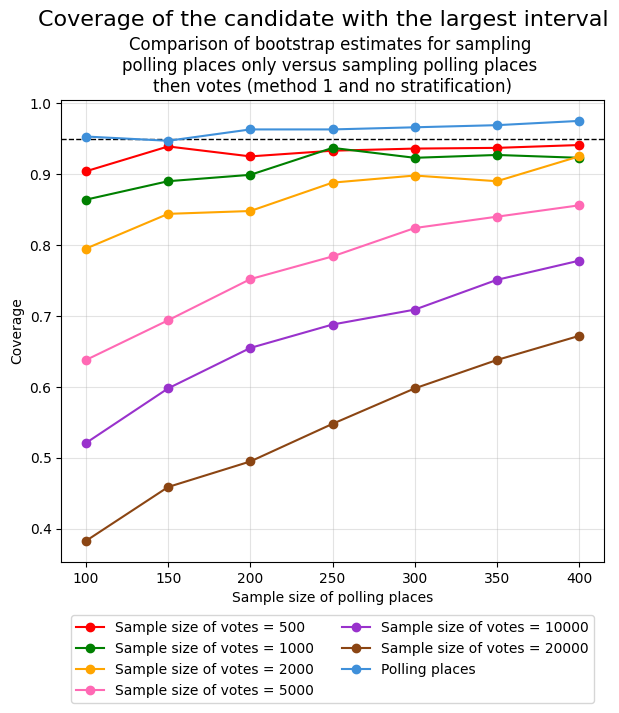

In [11]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)


# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique()):     
        plt.plot(df_boostraps_votos_se[(df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 df_boostraps_votos_se[(df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)]["Intervalo_M_grande_candidato_cob"],
                 color=colors_plot[ind_j], label=f'Sample size of votes = {j}', linestyle='solid',  marker='o')
        
# La gráfica de las casillas
plt.plot(df_boostraps_c_s_e["Tamaño_muestra_casillas"], df_boostraps_c_s_e["Intervalo_M_grande_candidato_cob"], color='C0', marker='o', label='Polling places')

plt.suptitle('Coverage of the candidate with the largest interval', fontsize=16, y=1.03)
plt.title('Comparison of bootstrap estimates for sampling \npolling places only versus sampling polling places \nthen votes (method 1 and no stratification)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Cambiamos el nombre de la leyenda
plt.legend(title='Votos o casillas');
plt.grid(alpha=0.35);


# Juntamos los títulos y las leyendas con un nombre
plt.legend( bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

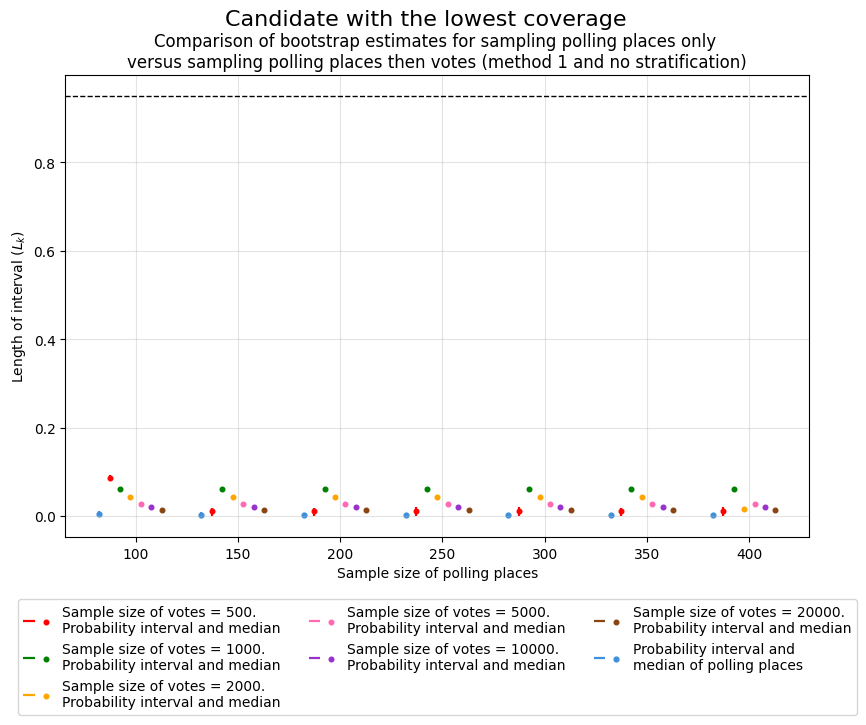

In [12]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(9.6, 6), dpi=100)
ax = fig.add_subplot(111)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]

# Lista de los labels de las gráficas
labels_votos = []

# Lista para guardar las gráficas
lista_graficas = []

# Para que no se crucen las líneas
offset = 5.1

# Primero hacemos un for para crear los valores para que no crucen las líneas
valores_x_grafica=[]
for ind_j, j in enumerate(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique()):
    k = 0
    for ind_i, i in enumerate(df_boostraps_votos_se["Tamaño_muestra_casillas"].unique()):

        # Slightly offset the x position for each subcategory
        valores_x_grafica.append( i + (ind_j - (len(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique())+1) / 2) * offset)


# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique()):
    l=0
    for ind_i, i in enumerate(df_boostraps_votos_se["Tamaño_muestra_casillas"].unique()):
              
        if l==0:
            # Slightly offset the x position for each subcategory
            x_position = i + (ind_j+1 - (len(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique())+1) / 2) * offset

            # Guardamos en lista los labels
            labels_votos.append(f"Sample size of votes = {j}. \nProbability interval and median")
            linea_1=ax.vlines(
                x_position,
                df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Cobertura_m_inter_q_025"].iloc[0],
                df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Cobertura_m_inter_q_975"].iloc[0],
                color=colors_plot[ind_j],
                linestyle="solid",
                label=f"Muestra votos = {j} (sin estratificar)",
                linewidth=1.6
            )
            punto_1=plt.scatter(x_position, df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Cobertura_m_inter_mediana"].iloc[0], color=colors_plot[ind_j], s=11)
            
            # Para que aparezcan los nombres
            lista_graficas.append((linea_1, punto_1))

        else:
            # Slightly offset the x position for each subcategory
            x_position = i + (ind_j+1 - (len(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique())+1) / 2) * offset

            # Guardamos en lista los labels
            #labels_votos.append(f"Sample size of votes = {j}. \nProbability interval and median")
            ax.vlines(
                x_position,
                df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Cobertura_m_inter_q_025"].iloc[0],
                df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Cobertura_m_inter_q_975"].iloc[0],
                color=colors_plot[ind_j],
                linestyle="solid",
                linewidth=1.6
            )
            plt.scatter(x_position, df_boostraps_votos_se[
            (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
            & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
        ]["Cobertura_m_inter_mediana"].iloc[0], color=colors_plot[ind_j], s=11)
            
        l=l+1


k=0

# Las gráficas de los intervalos de probabilidad de las casillas
for ind_i, i in enumerate(df_boostraps_c_s_e["Tamaño_muestra_casillas"].unique()):

    if k==0:
        x_position = valores_x_grafica[ind_i]
        # Guardamos en lista los labels
        labels_votos.append(f"Probability interval and \nmedian of polling places")
        linea_2=ax.vlines(
            x_position,
            df_boostraps_c_s_e[
                (df_boostraps_c_s_e["Tamaño_muestra_casillas"] == i)
            ]["Cobertura_m_inter_q_025"].iloc[0],
            df_boostraps_c_s_e[
                (df_boostraps_c_s_e["Tamaño_muestra_casillas"] == i)
            ]["Cobertura_m_inter_q_975"].iloc[0],
            linestyle="solid",
            label=f"Polling places",
            linewidth=1.6
        )
        # Graficamos las medianas
        punto_2=ax.scatter(x_position,df_boostraps_c_s_e[(df_boostraps_c_s_e["Tamaño_muestra_casillas"]==i)]["Cobertura_m_inter_mediana"].iloc[0], color='C0', s=12)
        # Para que aparezcan los nombres
        lista_graficas.append((linea_2, punto_2))
    else:
        x_position = valores_x_grafica[ind_i]
        # Guardamos en lista los labels
        #labels_votos.append(f"Probability interval of \npolling places")
        ax.vlines(
            x_position,
            df_boostraps_c_s_e[
                (df_boostraps_c_s_e["Tamaño_muestra_casillas"] == i)
            ]["Cobertura_m_inter_q_025"].iloc[0],
            df_boostraps_c_s_e[
                (df_boostraps_c_s_e["Tamaño_muestra_casillas"] == i)
            ]["Cobertura_m_inter_q_975"].iloc[0],
            linestyle="solid",
            linewidth=1.6
        )
        # Graficamos las medianas
        ax.scatter(x_position,df_boostraps_c_s_e[(df_boostraps_c_s_e["Tamaño_muestra_casillas"]==i)]["Cobertura_m_inter_mediana"].iloc[0], color='C0', s=12)
    k=l+1


# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.12), ncol=2, loc="upper center", numpoints=1)

lgnd = ax.legend(lista_graficas, labels_votos, bbox_to_anchor=(0.5, -0.12), ncol=3, loc="upper center", numpoints=1, handler_map = {tuple: legend_handler.HandlerTuple(None)})

plt.suptitle('Candidate with the lowest coverage', fontsize=16, y=0.99)
plt.title("Comparison of bootstrap estimates for sampling polling places only \nversus sampling polling places then votes (method 1 and no stratification)")

plt.xlabel('Sample size of polling places')
plt.ylabel('Length of interval ($L_{k}$)');
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
plt.grid(alpha=0.35);

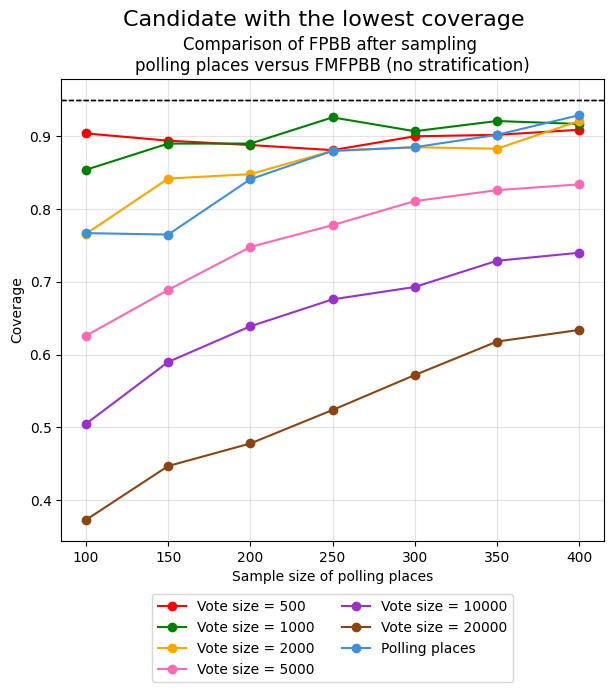

In [26]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)
# Guardar la gráfica
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique()):     
        plt.plot(df_boostraps_votos_se[(df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 df_boostraps_votos_se[(df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)]["Cobertura_m_candidato"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')
        
# La gráfica de las casillas
plt.plot(df_boostraps_c_s_e["Tamaño_muestra_casillas"], df_boostraps_c_s_e["Cobertura_m_candidato"], color='C0', marker='o', label='Polling places')

plt.suptitle('Candidate with the lowest coverage', fontsize=16, y=0.995)
plt.title('Comparison of FPBB after sampling \npolling places versus FMFPBB (no stratification)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Cambiamos el nombre de la leyenda
plt.grid(alpha=0.35);
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');


# Juntamos los títulos y las leyendas con un nombre
plt.legend( bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

### Gráficas de las coberturas por candidato

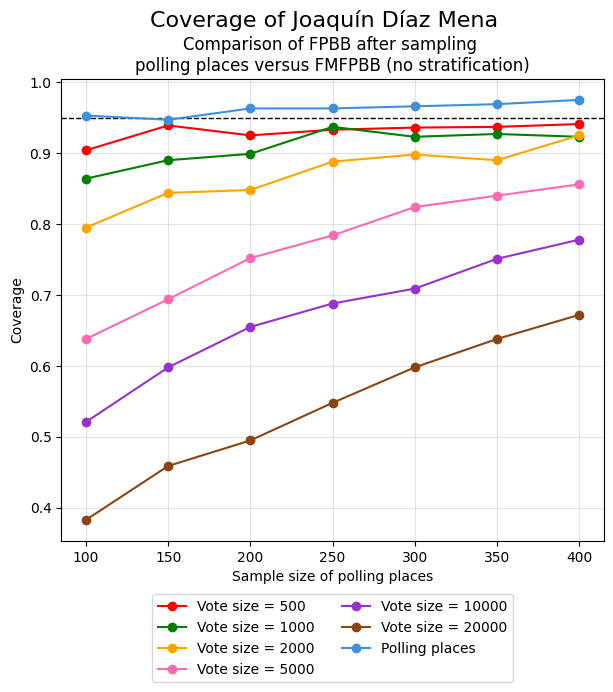

In [29]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)

# Guardar la gráfica
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique()):     
        plt.plot(df_boostraps_votos_se[(df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 df_boostraps_votos_se[(df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)]["Cob_JOAQUIN_DIAZ_MENA"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')
        
# La gráfica de las casillas
plt.plot(df_boostraps_c_s_e["Tamaño_muestra_casillas"], df_boostraps_c_s_e["Cob_JOAQUIN_DIAZ_MENA"], color='C0', marker='o', label='Polling places')

plt.suptitle('Coverage of Joaquín Díaz Mena', fontsize=16, y=0.995)
plt.title('Comparison of FPBB after sampling \npolling places versus FMFPBB (no stratification)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);

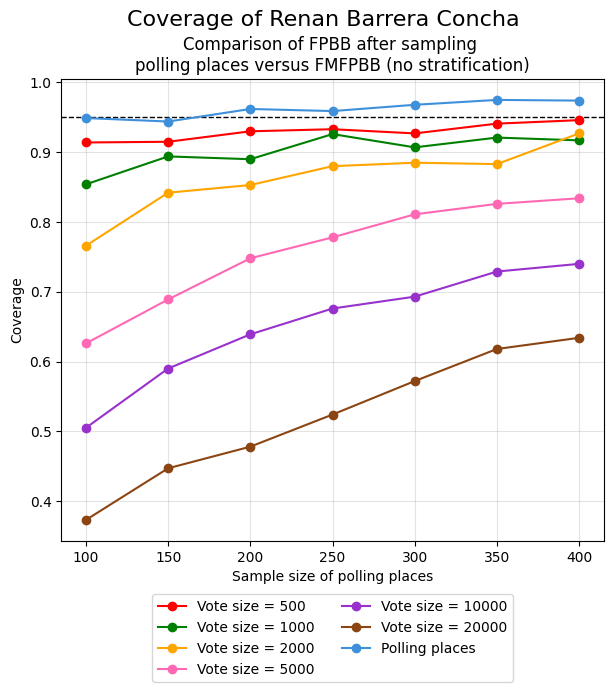

In [31]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)

# Guardar la gráfica
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique()):     
        plt.plot(df_boostraps_votos_se[(df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 df_boostraps_votos_se[(df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)]["Cob_RENAN_BARRERA_CONCHA"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')
        
# La gráfica de las casillas
plt.plot(df_boostraps_c_s_e["Tamaño_muestra_casillas"], df_boostraps_c_s_e["Cob_RENAN_BARRERA_CONCHA"], color='C0', marker='o', label='Polling places')

plt.suptitle('Coverage of Renan Barrera Concha', fontsize=16, y=0.995)
plt.title('Comparison of FPBB after sampling \npolling places versus FMFPBB (no stratification)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);

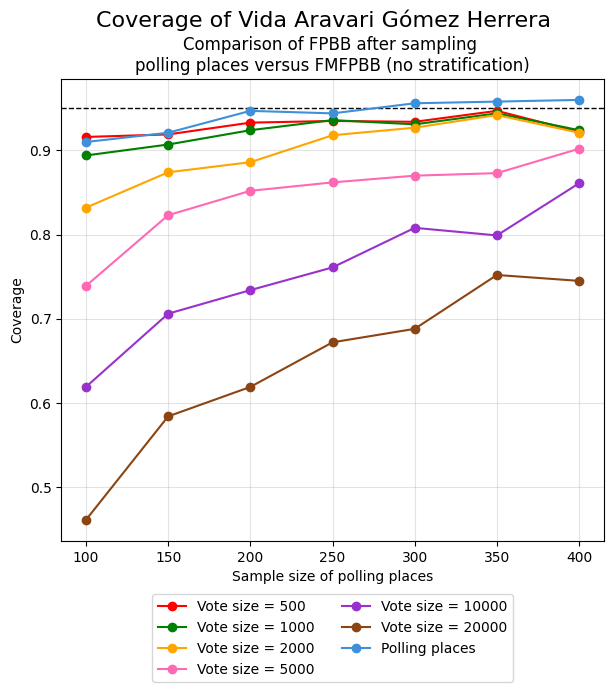

In [34]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)

# Guardar la gráfica
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique()):     
        plt.plot(df_boostraps_votos_se[(df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 df_boostraps_votos_se[(df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)]["Cob_VIDA_ARAVARI_GOMEZ_HERRERA"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')
        
# La gráfica de las casillas
plt.plot(df_boostraps_c_s_e["Tamaño_muestra_casillas"], df_boostraps_c_s_e["Cob_VIDA_ARAVARI_GOMEZ_HERRERA"], color='C0', marker='o', label='Polling places')

plt.suptitle('Coverage of Vida Aravari Gómez Herrera', fontsize=16, y=0.995)
plt.title('Comparison of FPBB after sampling \npolling places versus FMFPBB (no stratification)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);

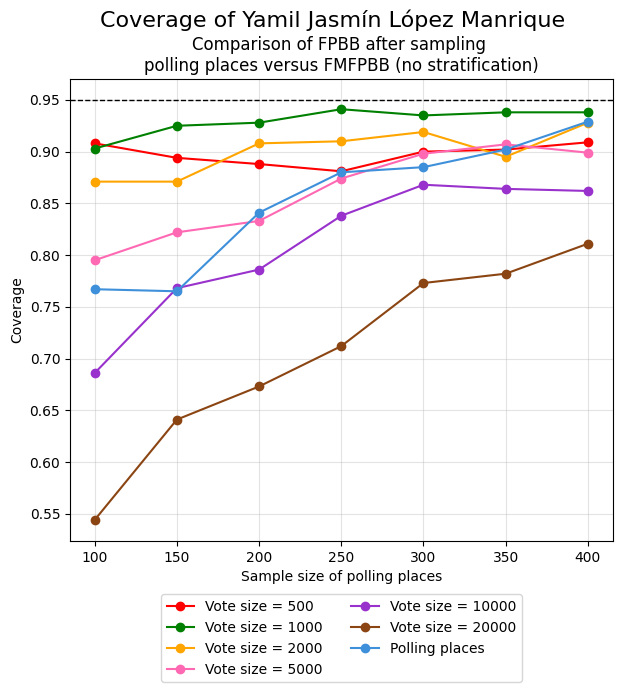

In [37]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)

# Guardar la gráfica
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique()):     
        plt.plot(df_boostraps_votos_se[(df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 df_boostraps_votos_se[(df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)]["Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')
        
# La gráfica de las casillas
plt.plot(df_boostraps_c_s_e["Tamaño_muestra_casillas"], df_boostraps_c_s_e["Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE"], color='C0', marker='o', label='Polling places')

plt.suptitle('Coverage of Yamil Jasmín López Manrique', fontsize=16, y=0.995)
plt.title('Comparison of FPBB after sampling \npolling places versus FMFPBB (no stratification)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);

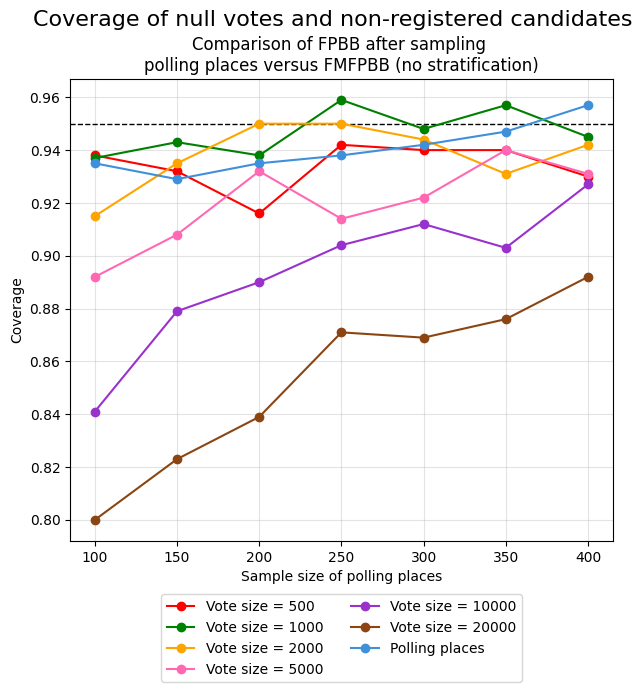

In [39]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)

# Guardar la gráfica
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique()):     
        plt.plot(df_boostraps_votos_se[(df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 df_boostraps_votos_se[(df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)]["Cob_VOTOS_NULOS_CAND_NO_REGIS"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')
        
# La gráfica de las casillas
plt.plot(df_boostraps_c_s_e["Tamaño_muestra_casillas"], df_boostraps_c_s_e["Cob_VOTOS_NULOS_CAND_NO_REGIS"], color='C0', marker='o', label='Polling places')

plt.suptitle('Coverage of null votes and non-registered candidates', fontsize=16, y=0.995)
plt.title('Comparison of FPBB after sampling \npolling places versus FMFPBB (no stratification)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);

## Comparación bootstraps estratificados

In [40]:
# Leemos las bases

# Base de bootstrap por casillas sin estratificar
df_boostraps_c_est=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases finales rep/Bootstrap por casillas/Distintas_muestras_casillas_bootstrap_estratificado_f_1.csv", index_col=0)
# Base de bootstrap por votos (submuestreo) método 1
df_boostraps_votos_est=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases finales rep/Bootstrap votos/Metodo 1/Distintas_muestras_submuestras_bootstrap_votos_met_1_estratificado_f_1.csv", index_col=0)

## Reducción del error

In [41]:
# Por casillas
1-df_boostraps_c_est["Error_maximo_mediana"].min()/df_boostraps_c_est["Error_maximo_mediana"].max()

np.float64(0.5100898301069591)

In [42]:
# Por casillas luego votos
b=df_boostraps_votos_est.groupby('Tamaño_submuestra_votos').agg({'Error_maximo_mediana':['max','min']})
b.columns=b.columns.map('_'.join)
b=b.reset_index()
b["Reduccion"]=1-b["Error_maximo_mediana_min"]/b["Error_maximo_mediana_max"]
b

,Tamaño_submuestra_votos,Error_maximo_mediana_max,Error_maximo_mediana_min,Reduccion
0,500,0.020439,0.018473,0.096203
1,1000,0.015259,0.013638,0.106258
2,2000,0.012976,0.010180,0.215479
3,5000,0.010168,0.007174,0.294495
4,10000,0.009189,0.005876,0.360524
5,20000,0.008716,0.005191,0.404415


## Reducción intervalo más largo

In [43]:
# Por casillas
1-df_boostraps_c_est["Intervalo_M_grande_inter_mediana"].min()/df_boostraps_c_est["Intervalo_M_grande_inter_mediana"].max()

np.float64(0.38188583431632017)

In [44]:
# Por casillas luego votos
a=df_boostraps_votos_est.groupby('Tamaño_submuestra_votos').agg({'Intervalo_M_grande_inter_mediana':['max','min']})
a.columns=a.columns.map('_'.join)
a=a.reset_index()
a["Reduccion"]=1-a["Intervalo_M_grande_inter_mediana_min"]/a["Intervalo_M_grande_inter_mediana_max"]
a

,Tamaño_submuestra_votos,Intervalo_M_grande_inter_mediana_max,Intervalo_M_grande_inter_mediana_min,Reduccion
0,500,0.082370,0.081911,0.005573
1,1000,0.059313,0.059217,0.001607
2,2000,0.042486,0.042186,0.007064
3,5000,0.027083,0.026910,0.006376
4,10000,0.019206,0.019127,0.004121
5,20000,0.013643,0.013592,0.003786


## Gráficas

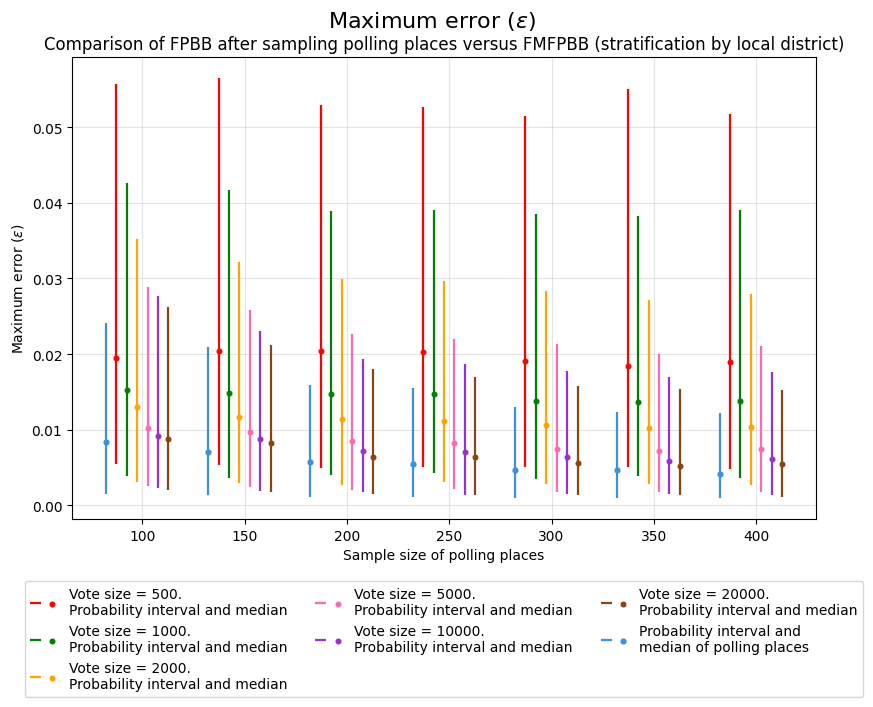

In [47]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(9.6, 6), dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(9.6, 6), dpi=350)

ax = fig.add_subplot(111)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]

# Lista de los labels de las gráficas
labels_votos = []

# Lista para guardar las gráficas
lista_graficas = []

# Para que no se crucen las líneas
offset = 5.1

# Primero hacemos un for para crear los valores para que no crucen las líneas
valores_x_grafica=[]
for ind_j, j in enumerate(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique()):
    k = 0
    for ind_i, i in enumerate(df_boostraps_votos_est["Tamaño_muestra_casillas"].unique()):

        # Slightly offset the x position for each subcategory
        valores_x_grafica.append( i + (ind_j - (len(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique())+1) / 2) * offset)


# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique()):
    l=0
    for ind_i, i in enumerate(df_boostraps_votos_est["Tamaño_muestra_casillas"].unique()):
              
        if l==0:
            # Slightly offset the x position for each subcategory
            x_position = i + (ind_j+1 - (len(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique())+1) / 2) * offset

            # Guardamos en lista los labels
            labels_votos.append(f"Vote size = {j}. \nProbability interval and median")
            linea_1=ax.vlines(
                x_position,
                df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Error_maximo_q_025"].iloc[0],
                df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Error_maximo_q_975"].iloc[0],
                color=colors_plot[ind_j],
                linestyle="solid",
                label=f"Muestra votos = {j} (sin estratificar)",
                linewidth=1.6
            )
            punto_1=plt.scatter(x_position, df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Error_maximo_mediana"].iloc[0], color=colors_plot[ind_j], s=11)
            
            # Para que aparezcan los nombres
            lista_graficas.append((linea_1, punto_1))


        else:
            # Slightly offset the x position for each subcategory
            x_position = i + (ind_j+1 - (len(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique())+1) / 2) * offset

            # Guardamos en lista los labels
            #labels_votos.append(f"Sample size of votes = {j}. \nProbability interval and median")
            ax.vlines(
                x_position,
                df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Error_maximo_q_025"].iloc[0],
                df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Error_maximo_q_975"].iloc[0],
                color=colors_plot[ind_j],
                linestyle="solid",
                linewidth=1.6
            )
            plt.scatter(x_position, df_boostraps_votos_est[
            (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
            & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
        ]["Error_maximo_mediana"].iloc[0], color=colors_plot[ind_j], s=11)
            
        l=l+1


k=0

# Las gráficas de los intervalos de probabilidad de las casillas
for ind_i, i in enumerate(df_boostraps_c_est["Tamaño_muestra_casillas"].unique()):

    if k==0:
        x_position = valores_x_grafica[ind_i]
        # Guardamos en lista los labels
        labels_votos.append(f"Probability interval and \nmedian of polling places")
        linea_2=ax.vlines(
            x_position,
            df_boostraps_c_est[
                (df_boostraps_c_est["Tamaño_muestra_casillas"] == i)
            ]["Error_maximo_q_025"].iloc[0],
            df_boostraps_c_est[
                (df_boostraps_c_est["Tamaño_muestra_casillas"] == i)
            ]["Error_maximo_q_975"].iloc[0],
            linestyle="solid",
            label=f"Polling places",
            linewidth=1.6
        )
        # Graficamos las medianas
        punto_2=ax.scatter(x_position,df_boostraps_c_est[(df_boostraps_c_est["Tamaño_muestra_casillas"]==i)]["Error_maximo_mediana"].iloc[0], color='C0', s=12)
        # Para que aparezcan los nombres
        lista_graficas.append((linea_2, punto_2))
    else:
        x_position = valores_x_grafica[ind_i]
        # Guardamos en lista los labels
        #labels_votos.append(f"Probability interval of \npolling places")
        ax.vlines(
            x_position,
            df_boostraps_c_est[
                (df_boostraps_c_est["Tamaño_muestra_casillas"] == i)
            ]["Error_maximo_q_025"].iloc[0],
            df_boostraps_c_est[
                (df_boostraps_c_est["Tamaño_muestra_casillas"] == i)
            ]["Error_maximo_q_975"].iloc[0],
            linestyle="solid",
            linewidth=1.6
        )
        # Graficamos las medianas
        ax.scatter(x_position,df_boostraps_c_est[(df_boostraps_c_est["Tamaño_muestra_casillas"]==i)]["Error_maximo_mediana"].iloc[0], color='C0', s=12)
    k=l+1


# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.12), ncol=2, loc="upper center", numpoints=1)

lgnd = ax.legend(lista_graficas, labels_votos, bbox_to_anchor=(0.5, -0.12), ncol=3, loc="upper center", numpoints=1, handler_map = {tuple: legend_handler.HandlerTuple(None)})

plt.suptitle("Maximum error ($\\epsilon$)", fontsize=16, y=0.96)
plt.title("Comparison of FPBB after sampling polling places versus FMFPBB (stratification by local district)")

plt.xlabel("Sample size of polling places")
plt.ylabel("Maximum error ($\\epsilon$)")

plt.grid(alpha=0.35)

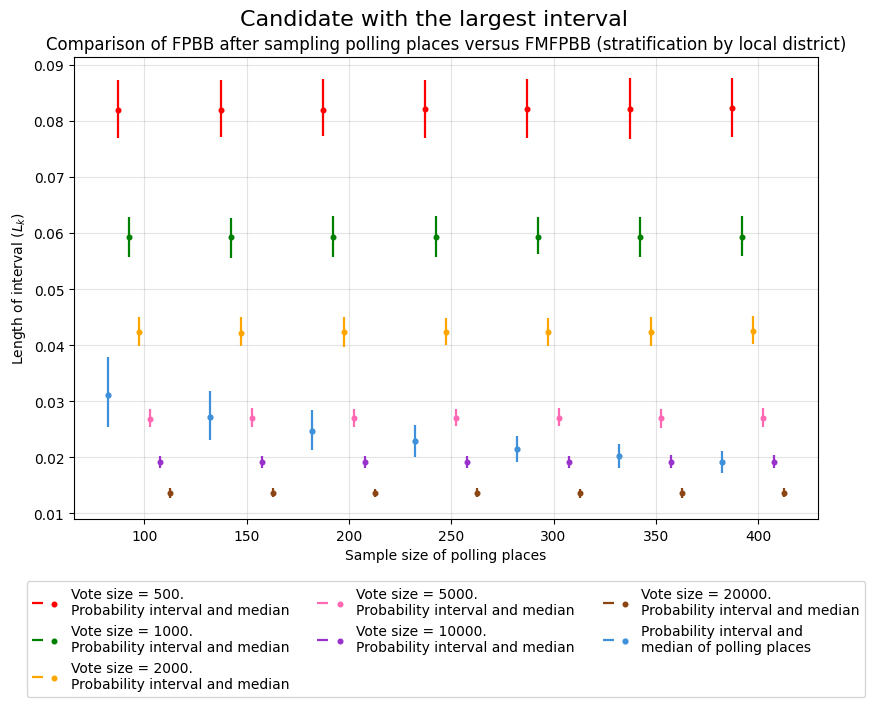

In [52]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(9.6, 6), dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(9.6, 6), dpi=350)
ax = fig.add_subplot(111)


# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]

# Lista de los labels de las gráficas
labels_votos = []

# Lista para guardar las gráficas
lista_graficas = []

# Para que no se crucen las líneas
offset = 5.1

# Primero hacemos un for para crear los valores para que no crucen las líneas
valores_x_grafica=[]
for ind_j, j in enumerate(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique()):
    k = 0
    for ind_i, i in enumerate(df_boostraps_votos_est["Tamaño_muestra_casillas"].unique()):

        # Slightly offset the x position for each subcategory
        valores_x_grafica.append( i + (ind_j - (len(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique())+1) / 2) * offset)


# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique()):
    l=0
    for ind_i, i in enumerate(df_boostraps_votos_est["Tamaño_muestra_casillas"].unique()):
              
        if l==0:
            # Slightly offset the x position for each subcategory
            x_position = i + (ind_j+1 - (len(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique())+1) / 2) * offset

            # Guardamos en lista los labels
            labels_votos.append(f"Vote size = {j}. \nProbability interval and median")
            linea_1=ax.vlines(
                x_position,
                df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Intervalo_M_grande_inter_q_025"].iloc[0],
                df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Intervalo_M_grande_inter_q_975"].iloc[0],
                color=colors_plot[ind_j],
                linestyle="solid",
                label=f"Muestra votos = {j} (sin estratificar)",
                linewidth=1.6
            )
            punto_1=plt.scatter(x_position, df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Intervalo_M_grande_inter_mediana"].iloc[0], color=colors_plot[ind_j], s=11)
            
            # Para que aparezcan los nombres
            lista_graficas.append((linea_1, punto_1))


        else:
            # Slightly offset the x position for each subcategory
            x_position = i + (ind_j+1 - (len(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique())+1) / 2) * offset

            # Guardamos en lista los labels
            #labels_votos.append(f"Sample size of votes = {j}. \nProbability interval and median")
            ax.vlines(
                x_position,
                df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Intervalo_M_grande_inter_q_025"].iloc[0],
                df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Intervalo_M_grande_inter_q_975"].iloc[0],
                color=colors_plot[ind_j],
                linestyle="solid",
                linewidth=1.6
            )
            plt.scatter(x_position, df_boostraps_votos_est[
            (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
            & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
        ]["Intervalo_M_grande_inter_mediana"].iloc[0], color=colors_plot[ind_j], s=11)
            
        l=l+1


k=0

# Las gráficas de los intervalos de probabilidad de las casillas
for ind_i, i in enumerate(df_boostraps_c_est["Tamaño_muestra_casillas"].unique()):

    if k==0:
        x_position = valores_x_grafica[ind_i]
        # Guardamos en lista los labels
        labels_votos.append(f"Probability interval and \nmedian of polling places")
        linea_2=ax.vlines(
            x_position,
            df_boostraps_c_est[
                (df_boostraps_c_est["Tamaño_muestra_casillas"] == i)
            ]["Intervalo_M_grande_inter_q_025"].iloc[0],
            df_boostraps_c_est[
                (df_boostraps_c_est["Tamaño_muestra_casillas"] == i)
            ]["Intervalo_M_grande_inter_q_975"].iloc[0],
            linestyle="solid",
            label=f"Polling places",
            linewidth=1.6
        )
        # Graficamos las medianas
        punto_2=ax.scatter(x_position,df_boostraps_c_est[(df_boostraps_c_est["Tamaño_muestra_casillas"]==i)]["Intervalo_M_grande_inter_mediana"].iloc[0], color='C0', s=12)
        # Para que aparezcan los nombres
        lista_graficas.append((linea_2, punto_2))
    else:
        x_position = valores_x_grafica[ind_i]
        # Guardamos en lista los labels
        #labels_votos.append(f"Probability interval of \npolling places")
        ax.vlines(
            x_position,
            df_boostraps_c_est[
                (df_boostraps_c_est["Tamaño_muestra_casillas"] == i)
            ]["Intervalo_M_grande_inter_q_025"].iloc[0],
            df_boostraps_c_est[
                (df_boostraps_c_est["Tamaño_muestra_casillas"] == i)
            ]["Intervalo_M_grande_inter_q_975"].iloc[0],
            linestyle="solid",
            linewidth=1.6
        )
        # Graficamos las medianas
        ax.scatter(x_position,df_boostraps_c_est[(df_boostraps_c_est["Tamaño_muestra_casillas"]==i)]["Intervalo_M_grande_inter_mediana"].iloc[0], color='C0', s=12)
    k=l+1


# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.12), ncol=2, loc="upper center", numpoints=1)

lgnd = ax.legend(lista_graficas, labels_votos, bbox_to_anchor=(0.5, -0.12), ncol=3, loc="upper center", numpoints=1, handler_map = {tuple: legend_handler.HandlerTuple(None)})

plt.suptitle('Candidate with the largest interval', fontsize=16, y=0.96)
plt.title("Comparison of FPBB after sampling polling places versus FMFPBB (stratification by local district)")

plt.xlabel('Sample size of polling places')
plt.ylabel('Length of interval ($L_{k}$)');
plt.grid(alpha=0.35);

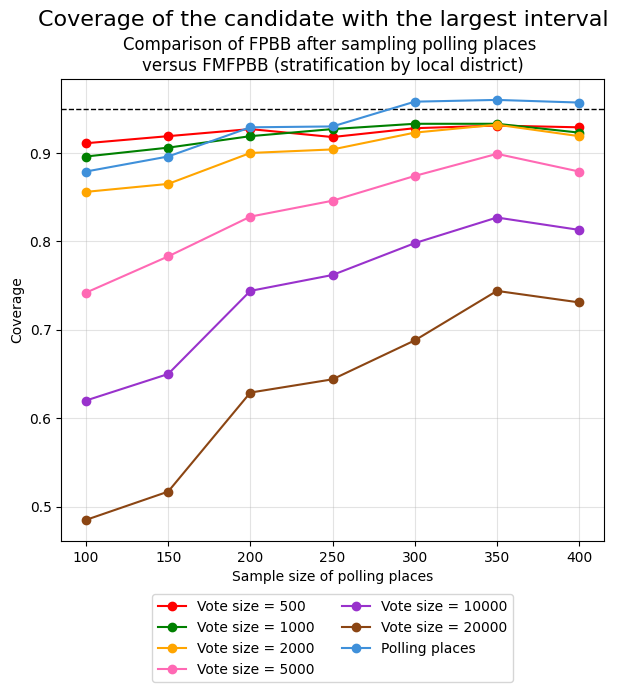

In [56]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique()):     
        plt.plot(df_boostraps_votos_est[(df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 df_boostraps_votos_est[(df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)]["Intervalo_M_grande_candidato_cob"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')
        
# La gráfica de las casillas
plt.plot(df_boostraps_c_est["Tamaño_muestra_casillas"], df_boostraps_c_est["Intervalo_M_grande_candidato_cob"], color='C0', marker='o', label='Polling places')

plt.suptitle('Coverage of the candidate with the largest interval', fontsize=16, y=0.995)
plt.title('Comparison of FPBB after sampling polling places \nversus FMFPBB (stratification by local district)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Cambiamos el nombre de la leyenda
plt.grid(alpha=0.35);


# Juntamos los títulos y las leyendas con un nombre
plt.legend( bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

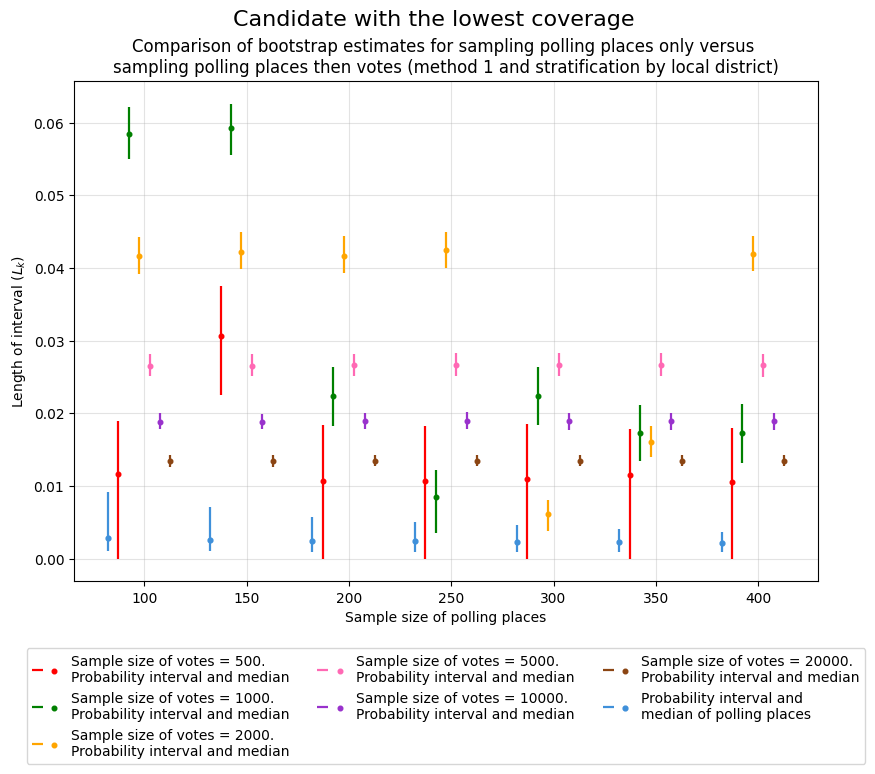

In [27]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(9.6, 6.5), dpi=100)
#fig = plt.figure(figsize=(9.6, 6.5), dpi=350)
ax = fig.add_subplot(111)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]

# Lista de los labels de las gráficas
labels_votos = []

# Lista para guardar las gráficas
lista_graficas = []

# Para que no se crucen las líneas
offset = 5.1

# Primero hacemos un for para crear los valores para que no crucen las líneas
valores_x_grafica=[]
for ind_j, j in enumerate(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique()):
    k = 0
    for ind_i, i in enumerate(df_boostraps_votos_est["Tamaño_muestra_casillas"].unique()):

        # Slightly offset the x position for each subcategory
        valores_x_grafica.append( i + (ind_j - (len(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique())+1) / 2) * offset)


# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique()):
    l=0
    for ind_i, i in enumerate(df_boostraps_votos_est["Tamaño_muestra_casillas"].unique()):
              
        if l==0:
            # Slightly offset the x position for each subcategory
            x_position = i + (ind_j+1 - (len(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique())+1) / 2) * offset

            # Guardamos en lista los labels
            labels_votos.append(f"Sample size of votes = {j}. \nProbability interval and median")
            linea_1=ax.vlines(
                x_position,
                df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Cobertura_m_inter_q_025"].iloc[0],
                df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Cobertura_m_inter_q_975"].iloc[0],
                color=colors_plot[ind_j],
                linestyle="solid",
                label=f"Muestra votos = {j} (sin estratificar)",
                linewidth=1.6
            )
            punto_1=plt.scatter(x_position, df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Cobertura_m_inter_mediana"].iloc[0], color=colors_plot[ind_j], s=11)
            
            # Para que aparezcan los nombres
            lista_graficas.append((linea_1, punto_1))

        else:
            # Slightly offset the x position for each subcategory
            x_position = i + (ind_j+1 - (len(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique())+1) / 2) * offset

            # Guardamos en lista los labels
            #labels_votos.append(f"Sample size of votes = {j}. \nProbability interval and median")
            ax.vlines(
                x_position,
                df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Cobertura_m_inter_q_025"].iloc[0],
                df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Cobertura_m_inter_q_975"].iloc[0],
                color=colors_plot[ind_j],
                linestyle="solid",
                linewidth=1.6
            )
            plt.scatter(x_position, df_boostraps_votos_est[
            (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
            & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
        ]["Cobertura_m_inter_mediana"].iloc[0], color=colors_plot[ind_j], s=11)
            
        l=l+1


k=0

# Las gráficas de los intervalos de probabilidad de las casillas
for ind_i, i in enumerate(df_boostraps_c_est["Tamaño_muestra_casillas"].unique()):

    if k==0:
        x_position = valores_x_grafica[ind_i]
        # Guardamos en lista los labels
        labels_votos.append(f"Probability interval and \nmedian of polling places")
        linea_2=ax.vlines(
            x_position,
            df_boostraps_c_est[
                (df_boostraps_c_est["Tamaño_muestra_casillas"] == i)
            ]["Cobertura_m_inter_q_025"].iloc[0],
            df_boostraps_c_est[
                (df_boostraps_c_est["Tamaño_muestra_casillas"] == i)
            ]["Cobertura_m_inter_q_975"].iloc[0],
            linestyle="solid",
            label=f"Polling places",
            linewidth=1.6
        )
        # Graficamos las medianas
        punto_2=ax.scatter(x_position,df_boostraps_c_est[(df_boostraps_c_est["Tamaño_muestra_casillas"]==i)]["Cobertura_m_inter_mediana"].iloc[0], color='C0', s=12)
        # Para que aparezcan los nombres
        lista_graficas.append((linea_2, punto_2))
    else:
        x_position = valores_x_grafica[ind_i]
        # Guardamos en lista los labels
        #labels_votos.append(f"Probability interval of \npolling places")
        ax.vlines(
            x_position,
            df_boostraps_c_est[
                (df_boostraps_c_est["Tamaño_muestra_casillas"] == i)
            ]["Cobertura_m_inter_q_025"].iloc[0],
            df_boostraps_c_est[
                (df_boostraps_c_est["Tamaño_muestra_casillas"] == i)
            ]["Cobertura_m_inter_q_975"].iloc[0],
            linestyle="solid",
            linewidth=1.6
        )
        # Graficamos las medianas
        ax.scatter(x_position,df_boostraps_c_est[(df_boostraps_c_est["Tamaño_muestra_casillas"]==i)]["Cobertura_m_inter_mediana"].iloc[0], color='C0', s=12)
    k=l+1


# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.12), ncol=2, loc="upper center", numpoints=1)

lgnd = ax.legend(lista_graficas, labels_votos, bbox_to_anchor=(0.5, -0.12), ncol=3, loc="upper center", numpoints=1, handler_map = {tuple: legend_handler.HandlerTuple(None)})

plt.suptitle('Candidate with the lowest coverage', fontsize=16, y=0.99)
plt.title("Comparison of bootstrap estimates for sampling polling places only versus \nsampling polling places then votes (method 1 and stratification by local district)")

plt.xlabel('Sample size of polling places')
plt.ylabel('Length of interval ($L_{k}$)');
plt.grid(alpha=0.35);

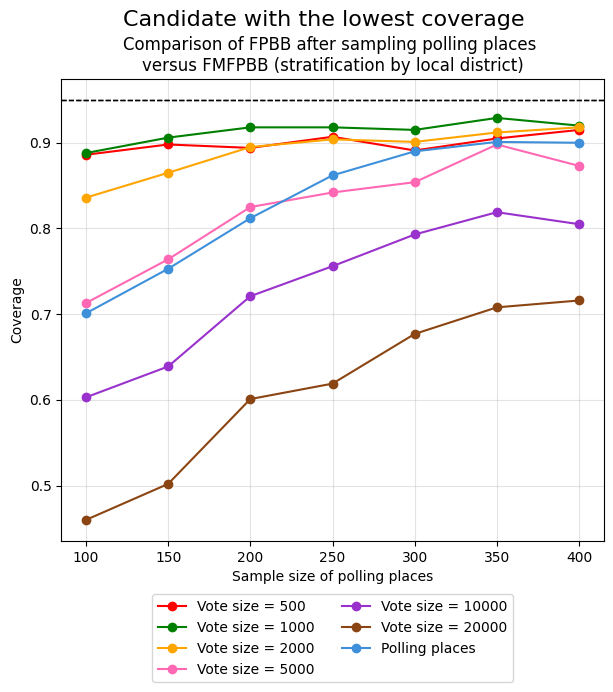

In [58]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)


# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique()):     
        plt.plot(df_boostraps_votos_est[(df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 df_boostraps_votos_est[(df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)]["Cobertura_m_candidato"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')
        
# La gráfica de las casillas
plt.plot(df_boostraps_c_est["Tamaño_muestra_casillas"], df_boostraps_c_est["Cobertura_m_candidato"], color='C0', marker='o', label='Polling places')

plt.suptitle('Candidate with the lowest coverage', fontsize=16, y=0.995)
plt.title('Comparison of FPBB after sampling polling places \nversus FMFPBB (stratification by local district)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Cambiamos el nombre de la leyenda
plt.grid(alpha=0.35);
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');


# Juntamos los títulos y las leyendas con un nombre
plt.legend( bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

### Gráficas de las coberturas por candidato

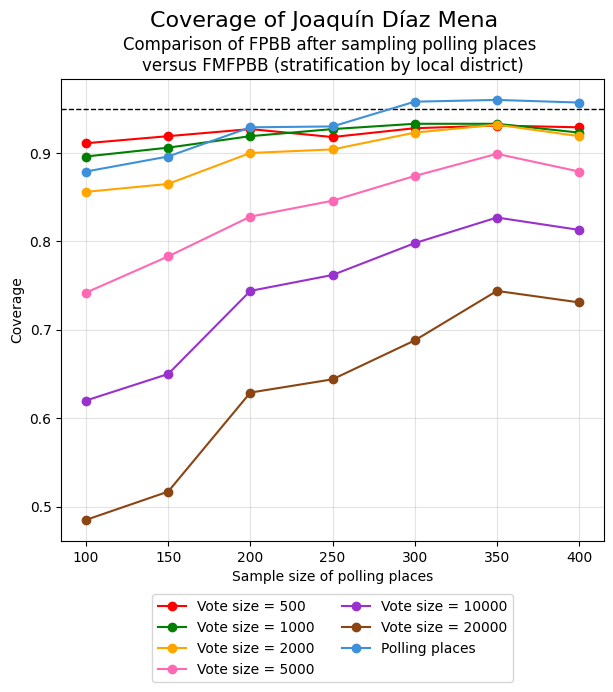

In [75]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique()):     
        plt.plot(df_boostraps_votos_est[(df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 df_boostraps_votos_est[(df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)]["Cob_JOAQUIN_DIAZ_MENA"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')
        
# La gráfica de las casillas
plt.plot(df_boostraps_c_est["Tamaño_muestra_casillas"], df_boostraps_c_est["Cob_JOAQUIN_DIAZ_MENA"], color='C0', marker='o', label='Polling places')

plt.suptitle('Coverage of Joaquín Díaz Mena', fontsize=16, y=0.995)
plt.title('Comparison of FPBB after sampling polling places \nversus FMFPBB (stratification by local district)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);
# Save image
plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_1/Estratificado/Joaquin_Diaz_Mena_casillas_sub_votos_vs_casillas_est.png", bbox_inches='tight',dpi=300);



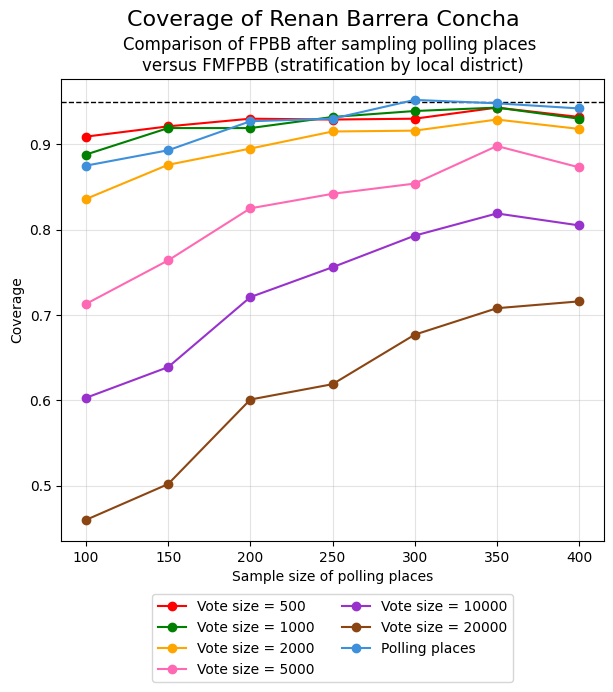

In [63]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique()):     
        plt.plot(df_boostraps_votos_est[(df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 df_boostraps_votos_est[(df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)]["Cob_RENAN_BARRERA_CONCHA"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')
        
# La gráfica de las casillas
plt.plot(df_boostraps_c_est["Tamaño_muestra_casillas"], df_boostraps_c_est["Cob_RENAN_BARRERA_CONCHA"], color='C0', marker='o', label='Polling places')

plt.suptitle('Coverage of Renan Barrera Concha', fontsize=16, y=0.995)
plt.title('Comparison of FPBB after sampling polling places \nversus FMFPBB (stratification by local district)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

# Save image
plt.grid(alpha=0.35);

plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_1/Estratificado/Renan_Barrera_Concha_casillas_sub_votos_vs_casillas_est.png", bbox_inches='tight',dpi=300);


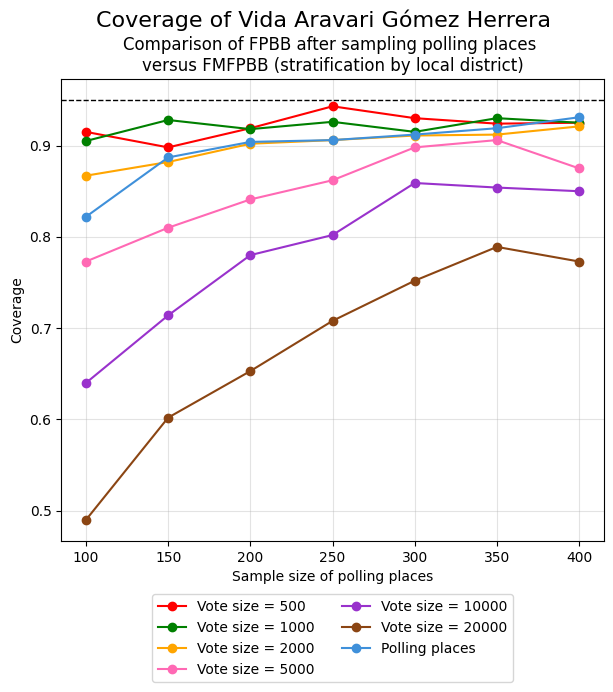

In [69]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique()):     
        plt.plot(df_boostraps_votos_est[(df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 df_boostraps_votos_est[(df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)]["Cob_VIDA_ARAVARI_GOMEZ_HERRERA"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')
        
# La gráfica de las casillas
plt.plot(df_boostraps_c_est["Tamaño_muestra_casillas"], df_boostraps_c_est["Cob_VIDA_ARAVARI_GOMEZ_HERRERA"], color='C0', marker='o', label='Polling places')

plt.suptitle('Coverage of Vida Aravari Gómez Herrera', fontsize=16, y=0.995)
plt.title('Comparison of FPBB after sampling polling places \nversus FMFPBB (stratification by local district)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);

plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_1/Estratificado/Vida_Aravari_Gomez_Herrera_casillas_sub_votos_vs_casillas_est.png", bbox_inches='tight',dpi=300);


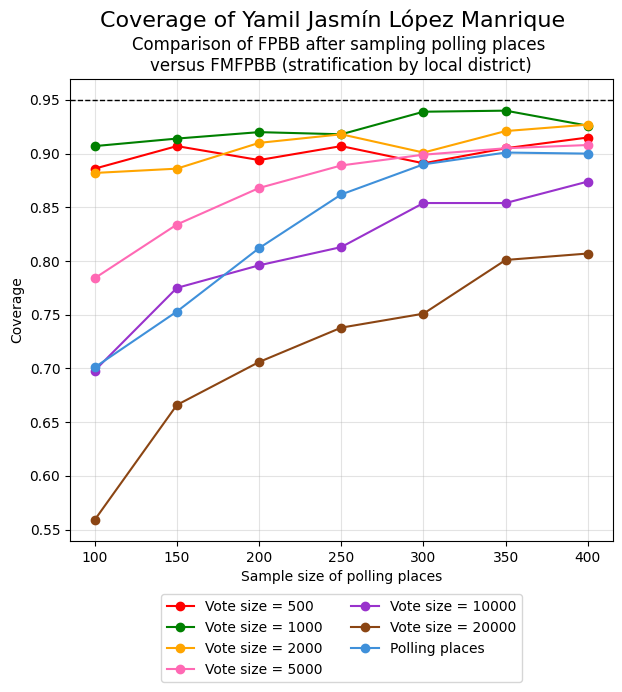

In [73]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique()):     
        plt.plot(df_boostraps_votos_est[(df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 df_boostraps_votos_est[(df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)]["Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')
        
# La gráfica de las casillas
plt.plot(df_boostraps_c_est["Tamaño_muestra_casillas"], df_boostraps_c_est["Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE"], color='C0', marker='o', label='Polling places')

plt.suptitle('Coverage of Yamil Jasmín López Manrique', fontsize=16, y=0.995)
plt.title('Comparison of FPBB after sampling polling places \nversus FMFPBB (stratification by local district)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);

plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_1/Estratificado/Jasmin_Lopez_Manrique_casillas_sub_votos_vs_casillas_est.png", bbox_inches='tight',dpi=300);


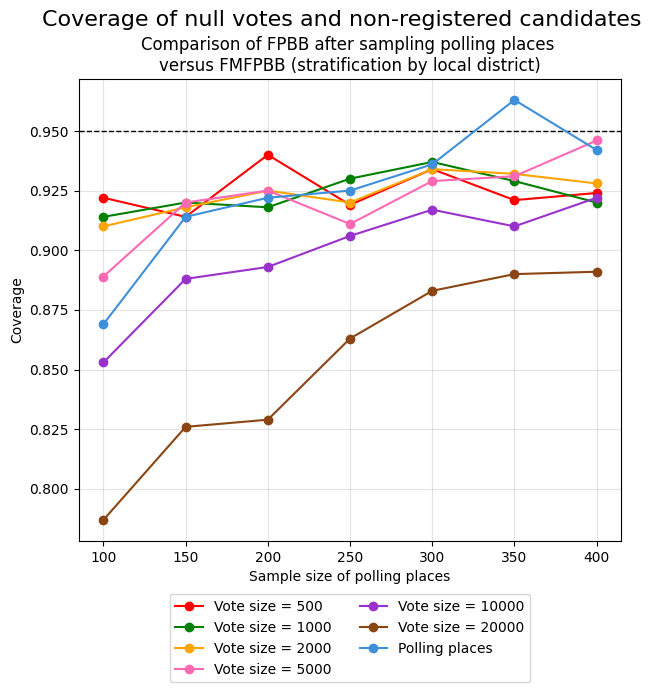

In [72]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique()):     
        plt.plot(df_boostraps_votos_est[(df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 df_boostraps_votos_est[(df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)]["Cob_VOTOS_NULOS_CAND_NO_REGIS"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')
        
# La gráfica de las casillas
plt.plot(df_boostraps_c_est["Tamaño_muestra_casillas"], df_boostraps_c_est["Cob_VOTOS_NULOS_CAND_NO_REGIS"], color='C0', marker='o', label='Polling places')

plt.suptitle('Coverage of null votes and non-registered candidates', fontsize=16, y=0.995)
plt.title('Comparison of FPBB after sampling polling places \nversus FMFPBB (stratification by local district)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);
plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_1/Estratificado/Votos_nulos_no_reg_casillas_sub_votos_vs_casillas_est.png", bbox_inches='tight',dpi=300);


## Conclusiones

**Los siguientes puntos aplican para el muestreo estratificado y no estratificado de votos**
- En terminos generales el bootstrap utilizando submuestreo de votos (boostrap de votos) tiene peores resultados que utilizando el bootstrap de solo casillas. Más aún, los errores, en el caso del bootstrap por casillas van disminuyendo conforme aumenta el número de casillas mientras que en el bootstrap por votos los errores se dismuyen muy poco con respecto a las casillas y realmente se ve su reducción cuando se incrementa el número de votos de la submuestra. Además, el decrecimiento del error es más rápido en el bootstrap de casillas que en el bootstrap de votos. Por lo tanto, a partir de 300 casillas el bootstrap por casillas tiene menor error (en el caso del estratificado), o el error es igual o ligeramente menor (en el caso de no estratificado) que la submuestra de votos con error más pequeño. En las longitudes de los intervalos de los candidatos con intervalos más grandes, sucede algo analógo a los errores. La única diferencia es que la longitud de los intervalos del bootstrap de votos no disminuye cuando se aumenta el número de casillas. 
- Por otra parte, para los candidatos con mayores porcentajes de votos las coberturas del candidato con menores cobertura son mayores en el bootstrap de casillas. Mientras que, para las coberturas del candidato con el menor cobertura el bootstrap por votos es igual o ligeramente mejor al bootstrap por casillas esto se debe a que:
    - En el caso del bootstrap por casillas el candidato con menor cobertura siempre es el mismo, el candidato con menor porcentaje de votos, (alrededor del 0.52%). Mientras que en el bootstrap por votos el candidato con menor cobertura va cambiando y no siempre es el mismo.
    - Las coberturas de los candidatos en el bootstrap por votos tienden a no tener mucha diferencia entre candidatos y todas están alrededor de 0.88 a 0.93, y aunque normalmente aumentan conforme se incrementa el número de casillas, este incremento no es uniforme ni tan rápido como el bootstrap de casillas. 
    - Por otro lado, las coberturas de los candidatos tienden a ser más grandes para aquellos que tengan mayor porcentaje de votos mayor y en particular la cobertura para el candidato con menor porcentaje de votos es mucho menor comparada con el resto de candidatos (no llega al 95%).
- Las diferencias entre las coberturas de los bootstraps se puede explicar porque en el caso del bootstrap por votos, se está submuestreando los votos de las casillas muestreadas por lo que es más probable que si sean muestreados todos los candidatos (sobre todo si se tiene una muestra de casillas suficientemente grande). En cambio, en el bootstrap por casillas como se muestrean las casillas, puede ocurrir que en simulaciones de la población se seleccionen casillas que no contengan votos del candidato con el menor porcentaje.
- Específicamente, para el boostrap de votos, sin importar la submuestra de votos (hasta 4000) o número de casillas (hasta 400), los intervalos de probabilidad de los errores siempre son mayores a 0.15. Aunado a esto, entre más crece el tamaño de la submuestra de votos menor son los intervalos de probabilidad del error. Esto se debe a que si tomamos mayor población mejor se representa la muestra de las casillas y por ende el error (que es el promedio de las estimaciones de los bootstrap menos el valor) se acerca más al valor real (a la muestra de casillas). Por otra parte, al aumentar el número de casillas también decrece el tamaño de los intervalos del error, aunque el decrecimeinto es más pequeño. Esto dado que, al tomar más casillas de la población y subsecuentemente al tomar votos de la misma, te aproximas más a muestrar aleatoriamente de toda la población. Lo cual reduce el error (el cual se calcula restando el promedio de estimación menos el valor real). 
- En el muestreo de votos, con respecto a la longitud de los intervalo (de porcentaje de votos), estos no cambian (o el cambia muy poco) al aumentar las casillas puesto que los intervalos solo se ven afectados por el tamaño de la submuestra de votos. Entre más votos tenga la submuestra mayor será su aproximación a la muestra de casillas y por ende habrá menor variabilidad. Nota: Esto solo aplica hasta cierto número de votos de la muestra, no es bueno tomar toda la muestra, en especial si se muestrearon pocas casillas. Para el candidato con intervalos más grandes, en ninguna combinación de submuestra de votos y muestra de casillas estos intervalos son menores a 0.025.
- En el muestreo de votos, las coberturas de los candidatos, aumentan entre más casillas se consideran, puesto que, al tomar más casillas de la población y subsecuentemente al tomar votos de la misma, te aproximas más a muestrar aleatoriamente de toda la población. En general tiene mejor cobertura tomar una menor cantidad de votos aunque tomar entre 500 a 2000 votos de submuestra tienen coberturas parecidas, sobre todo al tomar más de 200 casillas. Mientras que tomar más de 2000 votos de submuestra nos da las peores coberturas, menores o cercanas a 0.9 para el candidato con menor cobertura aún 400 casillas. Lo anterior se debe a que si se toma una submuestra mayor de votos (más de 2000) en una muestra de casillas pequeña, la variabilidad de los pesos Dirichlet es menor y por ende la población generada por el boostrap se va a asemeja más a la muestra de casillas, la cual no siempre es representativa de toda la población y por ende la cobertura es menor. Por lo que, al aumentar la muestra de casillas, la muestra es más representativa de la población y por lo tanto, la cobertura con submuestras más grandes de votos (más de 2000) se acerca a la cobertura de las submuestras más pequeñas (algo similar ocurre con el bootstrap frecuentista). Por último, en ninguna combinación de submuestra de votos y muestra de casillas, ningún candidato (o casi ninguno) alcanza la cobertura del 95%.

**Este punto es para la comparación entre el muestreo estratificado y no estratificado de votos**
- Por último, al utilizar la estratificación (por distrito) en el bootstrap de votos, se reduce el error y los cuantiles de las longitudes de los intervalos comparado con el bootstrap de votos sin estratificar. Mientras que las coberturas de los candidatos son ligeramente mejores en el bootstrap de votos sin estratificar que en el estratificado, aunque la diferencia no es mucha.